<a id="top"></a>
# Marketing bancario: validazione del primo modello

La fase di preparazione ha prodotto un dataset numerico, senza valori mancanti, adatto a un modello di classificazione binaria che preveda la sottoscrizione del deposito. 
Qui l’attenzione si sposta sulla **validazione**: quanto si può considerare affidabile il modello su clienti mai visti prima e in che misura risponde alla richiesta del business.

<a id="indice"></a>
## Indice

- [Obiettivo del modulo e dataset di partenza](#obiettivo-modulo)
- [Ricostruzione rapida del dataset per il modello](#dataset-modello)
- [Train/test split e class imbalance](#train-test)
- [Metriche per un problema sbilanciato](#metriche-sbilanciato)
- [Curva ROC e AUROC](#roc-auroc)
- [Curva precision-recall e AUPR](#pr-curve)
- [Matrice di confusione e costi di errore](#confusione)
- [Dalle metriche alle leve di business](#bridge-explain)
- [Permutation Feature Importance](#pfi)
- [SHAP summary plot](#shap)
- [Sintesi operativa](#sintesi)


<a id="obiettivo-modulo"></a>
## Obiettivo del modulo e dataset di partenza

Il team marketing ha chiesto un **PoC** che risponda a due domande essenziali:

1. *È realistico prevedere quali clienti sottoscriveranno il deposito?*
2. *Se la risposta è sì, quali fattori incidono di più sulla probabilità di sottoscrizione?*

Per la prima domanda serve una **misura quantitativa** delle prestazioni del modello su dati non utilizzati in addestramento.
Per la seconda serve una **lettura strutturata delle feature**, che consenta di trasformare il modello in indicazioni operative.

Tutto il lavoro parte dal dataset costruito nel modulo di preparazione, dove:
- il target `y` è binario (1 = sottoscrive il deposito, 0 = non sottoscrive);
- le feature sono numeriche, prive di valori mancanti, con `duration` esclusa dalle variabili di input.

<div style="background-color:#f5f5f5; padding:10px; border-left:4px solid #999;">
<strong>Nota importante</strong><br>
Senza una metrica chiara non si può dire se il PoC abbia raggiunto il livello richiesto dal business.
Si può migliorare solo ciò che viene misurato in modo coerente e ripetibile.
</div>


<a id="dataset-modello"></a>
## Costruzione dataset e pipeline di preprocessing

In questo modulo utilizziamo la stessa pipeline di preprocessing strutturata vista in T2, basata su `ColumnTransformer` e `Pipeline` di scikit-learn.

L'approccio a pipeline garantisce:
- **Coerenza** tra training e test (stessi transformer, stessi parametri)
- **Riproducibilità** (l'intera catena di trasformazioni è serializzabile)
- **Manutenibilità** (modifiche centralizzate invece di codice sparso)

La pipeline gestisce:
- encoding delle variabili binarie (`default`, `housing`);
- encoding ordinale di `education` e `month`;
- one-hot encoding delle variabili categoriali nominali (`job`, `marital`, `poutcome`);
- standardizzazione delle variabili numeriche.

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Caricamento del dataset Bank Marketing (id=222 nel repository UCI)
bank_marketing = fetch_ucirepo(id=222)

X_raw = bank_marketing.data.features
y_raw = bank_marketing.data.targets

df = X_raw.copy()
if isinstance(y_raw, pd.DataFrame):
    if y_raw.shape[1] == 1:
        df["y"] = y_raw.iloc[:, 0]
    else:
        for col in y_raw.columns:
            df[col] = y_raw[col]
else:
    df["y"] = y_raw

print("Shape feature raw:", X_raw.shape)
print("Shape target raw:", y_raw.shape)
df.head()


Shape feature raw: (45211, 16)
Shape target raw: (45211, 1)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [2]:
# Configuriamo scikit-learn per restituire DataFrame invece di array NumPy
from sklearn import set_config
set_config(transform_output="pandas")

# Selezione del sottoinsieme di feature come in T2
target_col = "y"

binary_cols = ["default", "housing"]
nominal_cols = ["job", "marital", "poutcome"]
ordinal_cols = ["education", "month"]
numeric_cols = ["age", "balance", "pdays", "previous"]

feature_cols = binary_cols + nominal_cols + ordinal_cols + numeric_cols

# Creiamo il DataFrame del modello (escludiamo duration per evitare leakage)
df_model = df[feature_cols + [target_col]].copy()

# Mappiamo il target a 0/1
y = df_model[target_col].map({"no": 0, "yes": 1}).astype("int8")
X = df_model[feature_cols]

print(f"Feature selezionate: {len(feature_cols)}")
print(f"Target binario: {y.value_counts().to_dict()}")
X.head()

Feature selezionate: 11
Target binario: {0: 39922, 1: 5289}


,default,housing,job,marital,poutcome,education,month,age,balance,pdays,previous
0,no,yes,management,married,NaN,tertiary,may,58,2143,-1,0
1,no,yes,technician,single,NaN,secondary,may,44,29,-1,0
2,no,yes,entrepreneur,married,NaN,secondary,may,33,2,-1,0
3,no,yes,blue-collar,married,NaN,NaN,may,47,1506,-1,0
4,no,no,NaN,single,NaN,NaN,may,33,1,-1,0


In [3]:
# Costruzione della pipeline di preprocessing (come in T2)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Encoder per variabili binarie (yes/no -> 0/1)
binary_encoder = OrdinalEncoder(
    categories=[["no", "yes"], ["no", "yes"]],
    dtype=float,
)

# Encoder per variabili ordinali con ordine logico
education_order = ["primary", "secondary", "tertiary"]
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec",
]

ordinal_encoder = OrdinalEncoder(
    categories=[education_order, month_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=float,
)

# Encoder per variabili nominali (one-hot)
nominal_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

# Scaler per variabili numeriche
numeric_scaler = StandardScaler()

# ColumnTransformer che combina tutti i preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_encoder, binary_cols),
        ("ord", ordinal_encoder, ordinal_cols),
        ("nom", nominal_encoder, nominal_cols),
        ("num", numeric_scaler, numeric_cols),
    ]
)

print("Pipeline di preprocessing creata con successo")
preprocessor

Pipeline di preprocessing creata con successo


,transformers,"[('bin', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,"[['no', 'yes'], ['no', 'yes']]"
,dtype,<class 'float'>
,handle_unknown,'error'


<a id="train-test"></a>
## Train/test split e class imbalance

Per valutare la **capacità di generalizzazione** del modello si separa il dataset in due parti:

- un **train set** usato per addestrare il modello;
- un **test set** usato solo per valutare il comportamento su clienti non visti.

Il dataset è sbilanciato: i clienti che sottoscrivono il deposito (`y = 1`) sono una minoranza.
Prima di addestrare il modello conviene quantificare questo squilibrio e fissare una baseline ingenua.


In [4]:
from sklearn.model_selection import train_test_split

# Distribuzione del target complessiva
target_counts = y.value_counts(normalize=True).sort_index()
print("Distribuzione relativa del target (0/1):")
print(target_counts)

# Train/test split con stratificazione sul target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nPrime righe di X_train (raw):")
X_train.head()

Distribuzione relativa del target (0/1):
y
0    0.883015
1    0.116985
Name: proportion, dtype: float64
Train shape: (36168, 11)
Test shape: (9043, 11)

Prime righe di X_train (raw):
Train shape: (36168, 11)
Test shape: (9043, 11)

Prime righe di X_train (raw):


,default,housing,job,marital,poutcome,education,month,age,balance,pdays,previous
24001,no,no,technician,divorced,NaN,secondary,aug,36,861,-1,0
43409,no,no,student,single,failure,secondary,apr,24,4126,185,7
20669,no,yes,technician,single,NaN,secondary,aug,44,244,-1,0
18810,no,no,unemployed,married,NaN,secondary,jul,48,0,-1,0
23130,no,no,technician,married,NaN,secondary,aug,38,257,-1,0


<div style="background-color:#fff3cd; padding:10px; border-left:4px solid #c69500;">
<strong>Attenzione</strong><br>
Il test set deve restare "pulito": va usato una sola volta per stimare le prestazioni del modello.
Se iperparametri e scelte di feature vengono continuamente modificati guardando al test, 
la stima finale risulta troppo ottimistica.
</div>


<a id="metriche-sbilanciato"></a>
## Metriche per un problema sbilanciato

In un dataset sbilanciato l’**accuratezza** può essere fuorviante.
Un classificatore che predice sempre la classe maggioritaria ottiene un’accuracy elevata,
ma non risolve il problema del business perché non individua quasi mai i clienti che sottoscrivono.

Servono metriche che tengano conto della separazione tra le due classi:

- **AUROC** (Area Under ROC Curve): misura la capacità del modello di ordinare correttamente i positivi rispetto ai negativi;
- **AUPR** (Area Under Precision-Recall Curve): mette l’accento sulle prestazioni nella classe positiva, utile quando i positivi sono pochi.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Creiamo una pipeline completa: preprocessing + modello
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Addestriamo la pipeline su train (il preprocessing avviene automaticamente)
pipeline.fit(X_train, y_train)

# Baseline ingenua: predire sempre la classe più frequente del train
majority_class = y_train.value_counts().idxmax()
y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
model_acc = accuracy_score(y_test, pipeline.predict(X_test))

print(f"Accuracy baseline (sempre classe {majority_class}): {baseline_acc:.3f}")
print(f"Accuracy modello Random Forest: {model_acc:.3f}")

Accuracy baseline (sempre classe 0): 0.883
Accuracy modello Random Forest: 0.889


<a id="roc-auroc"></a>
## Curva ROC e AUROC

La **curva ROC** (Receiver Operating Characteristic) rappresenta il compromesso tra:

- *True Positive Rate* (sensibilità): quota di positivi correttamente identificati;
- *False Positive Rate*: quota di negativi classificati erroneamente come positivi.

L’**AUROC** è l’area sotto questa curva. Valori vicini a 0.5 indicano un modello poco utile,
valori più alti indicano una migliore separazione tra clienti che sottoscrivono e clienti che non sottoscrivono.


AUROC: 0.742


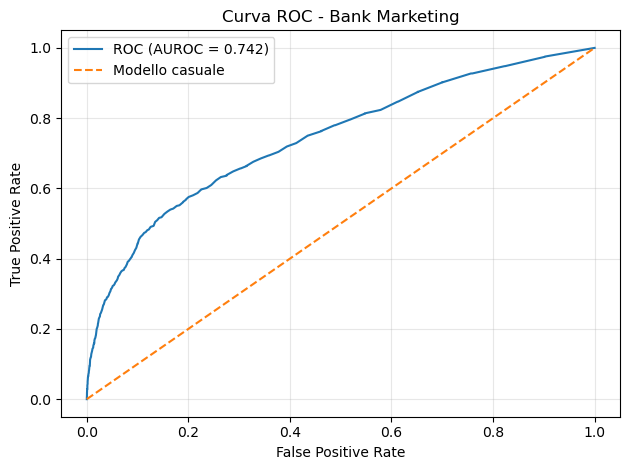

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilità previste per la classe positiva (la pipeline gestisce automaticamente il preprocessing)
y_proba_test = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
auroc = roc_auc_score(y_test, y_proba_test)

print(f"AUROC: {auroc:.3f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUROC = {auroc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modello casuale")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Bank Marketing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="pr-curve"></a>
## Curva precision-recall e AUPR

Quando la classe positiva è rara, la **curva precision-recall** spesso racconta meglio il comportamento del modello.

- La **precision** indica quale quota dei clienti classificati come positivi sottoscrive davvero;
- il **recall** coincide con la sensibilità, cioè la quota di clienti che sottoscrive e viene correttamente intercettata.

L’**AUPR** sintetizza l’andamento della curva: valori più alti indicano un modello capace di mantenere una buona precision
anche a livelli di recall interessanti per la campagna.


AUPR (Average Precision): 0.371


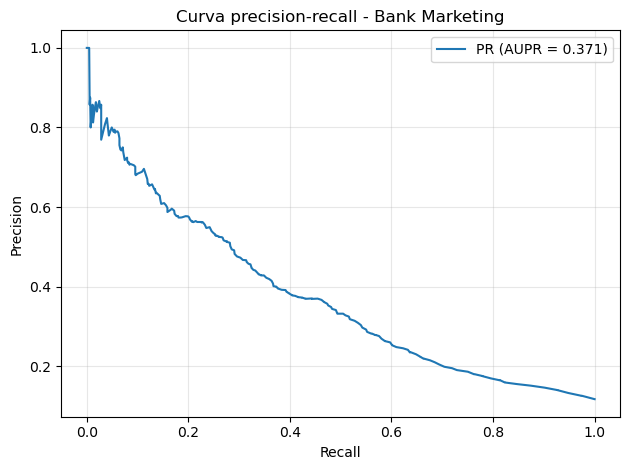

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Utilizziamo le stesse probabilità calcolate prima
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_test)
aupr = average_precision_score(y_test, y_proba_test)

print(f"AUPR (Average Precision): {aupr:.3f}")

plt.figure()
plt.plot(recall, precision, label=f"PR (AUPR = {aupr:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva precision-recall - Bank Marketing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="confusione"></a>
## Matrice di confusione e costi di errore

Le curve ROC e precision-recall riassumono bene il comportamento del modello su tutte le soglie possibili.
Per passare a decisioni concrete serve anche una lettura in termini di **conteggi di casi corretti e sbagliati**.

La **matrice di confusione** mette in evidenza:

- *True Negative* (TN): clienti correttamente classificati come non sottoscrittori;
- *False Positive* (FP): clienti contattati e classificati come interessati ma che non sottoscrivono;
- *False Negative* (FN): clienti che avrebbero sottoscritto ma che il modello non segnala;
- *True Positive* (TP): clienti correttamente identificati come sottoscrittori.

Nel contesto della campagna:
- gli FP rappresentano chiamate "sprecate" (tempo del call center, possibile fastidio per il cliente);
- gli FN rappresentano opportunità perse di sottoscrizione.


In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# Predizioni finali usando la pipeline
y_pred_test = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)

tn, fp, fn, tp = cm.ravel()
print("Matrice di confusione (righe = vero, colonne = predetto):")
print(cm)
print()
print(f"TN (veri negativi): {tn}  |  FP (falsi positivi): {fp}")
print(f"FN (falsi negativi): {fn}  |  TP (veri positivi): {tp}")
print()
print(classification_report(y_test, y_pred_test, target_names=["No", "Yes"]))

Matrice di confusione (righe = vero, colonne = predetto):
[[7798  187]
 [ 819  239]]

TN (veri negativi): 7798  |  FP (falsi positivi): 187
FN (falsi negativi): 819  |  TP (veri positivi): 239

              precision    recall  f1-score   support

          No       0.90      0.98      0.94      7985
         Yes       0.56      0.23      0.32      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.60      0.63      9043
weighted avg       0.86      0.89      0.87      9043



<div style="background-color:#f5f5f5; padding:10px; border-left:4px solid #999;">
<strong>Esercizio</strong><br>
Varia il parametro <code>n_estimators</code> della Random Forest e osserva come cambiano AUROC, AUPR e matrice di confusione.
</div>


<a id="bridge-explain"></a>
## Dalle metriche alle leve di business

Le metriche sul test set danno una prima risposta alla domanda *“il modello funziona abbastanza bene?”*.
Per trasformare il PoC in uno strumento utile al marketing manca però un tassello: capire **da cosa dipendono**
le probabilità di sottoscrizione.

Il team chiede di identificare:
- quali feature hanno l’impatto maggiore sulle previsioni;
- in che direzione agiscono sui singoli clienti.

Si introducono quindi due strumenti complementari:

- la **Permutation Feature Importance** (PFI), che misura quanto peggiorano le prestazioni quando una feature viene permutata;
- i **valori SHAP**, che decomponogno la previsione di ogni cliente come somma di contributi delle singole feature.


<a id="pfi"></a>
## Permutation Feature Importance

La **Permutation Feature Importance** valuta l’importanza di una feature misurando quanto peggiora una metrica
di interesse quando i valori di quella feature vengono permutati in modo casuale.

In scikit-learn è implementata in `sklearn.inspection.permutation_importance`.
Documentazione: https://scikit-learn.org/stable/modules/permutation_importance.html


In [9]:
from sklearn.inspection import permutation_importance

# Con la pipeline, passiamo i dati raw (X_test) - il preprocessing è integrato
result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances_mean = result.importances_mean
importances_std = result.importances_std

# I nomi delle feature sono quelli originali di X_test
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importances_mean,
    "importance_std": importances_std,
}).sort_values("importance_mean", ascending=False)

feature_importance.head(10)

,feature,importance_mean,importance_std
4,poutcome,0.011478,0.000654
6,month,0.004976,0.000807
9,pdays,0.003671,0.000654
1,housing,0.003517,0.001022
8,balance,0.001747,0.000826
3,marital,0.000774,0.000833
10,previous,0.000575,0.000826
0,default,0.000066,0.000150
5,education,0.000022,0.000913
2,job,-0.000509,0.000835


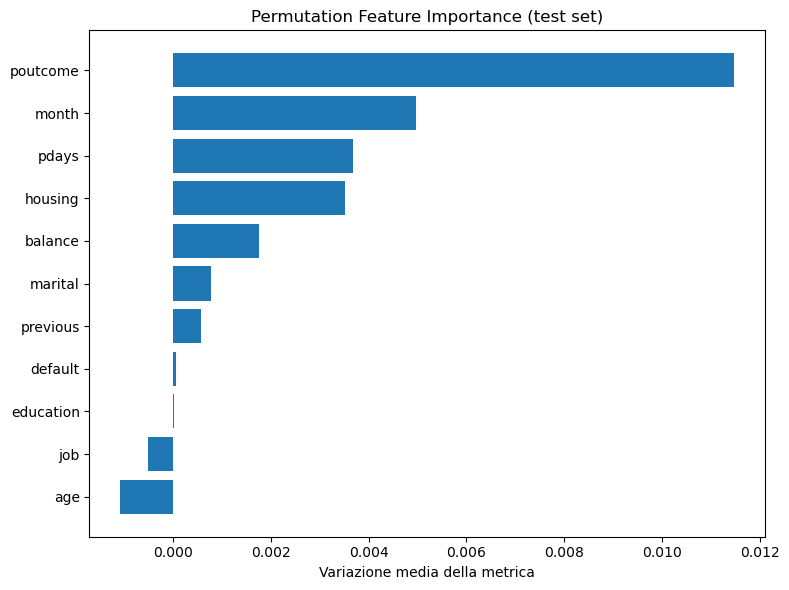

In [10]:
# Visualizzazione delle prime 15 feature per importanza permutazionale
top_n = 15
fi_top = feature_importance.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(fi_top["feature"][::-1], fi_top["importance_mean"][::-1])
plt.xlabel("Variazione media della metrica")
plt.title("Permutation Feature Importance (test set)")
plt.tight_layout()
plt.show()


<a id="shap"></a>
## SHAP summary plot

I **valori SHAP** (SHapley Additive exPlanations) forniscono una decomposizione additiva della previsione di un modello
in contributi delle singole feature. Per ogni cliente è possibile vedere quali variabili spingono la probabilità di
sottoscrizione verso l’alto o verso il basso.

Per modelli ad alberi come la Random Forest esiste un `TreeExplainer` dedicato.
Documentazione: https://shap.readthedocs.io/en/latest/


In [15]:
import shap

# Campione del test set
X_test_sample = X_test.sample(100, random_state=42)

# Per usare SHAP con una Pipeline, dobbiamo passare i dati preprocessati
# Estraiamo il preprocessor e applichiamolo al campione
X_test_sample_transformed = pipeline.named_steps['preprocess'].transform(X_test_sample)

# SHAP lavora sul modello finale (Random Forest)
explainer = shap.TreeExplainer(pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_test_sample_transformed)


In [16]:
shap_values

array([[[-2.37864690e-04,  2.37864690e-04],
        [-2.28510305e-02,  2.28510305e-02],
        [ 5.07524600e-03, -5.07524600e-03],
        ...,
        [ 1.91512915e-02, -1.91512915e-02],
        [ 1.12257686e-02, -1.12257686e-02],
        [ 9.59303896e-03, -9.59303896e-03]],

       [[-2.84571903e-04,  2.84571903e-04],
        [-2.08373752e-02,  2.08373752e-02],
        [-4.96088729e-04,  4.96088729e-04],
        ...,
        [ 7.99704080e-04, -7.99704080e-04],
        [ 1.07051285e-02, -1.07051285e-02],
        [ 1.05552306e-02, -1.05552306e-02]],

       [[-4.34150507e-04,  4.34150507e-04],
        [-4.46421532e-02,  4.46421532e-02],
        [-2.46744077e-02,  2.46744077e-02],
        ...,
        [-1.77251687e-03,  1.77251687e-03],
        [-5.72516567e-03,  5.72516567e-03],
        [-3.65679356e-02,  3.65679356e-02]],

       ...,

       [[-1.74317484e-05,  1.74317484e-05],
        [ 1.55883192e-03, -1.55883192e-03],
        [ 1.65954283e-02, -1.65954283e-02],
        ...,
     

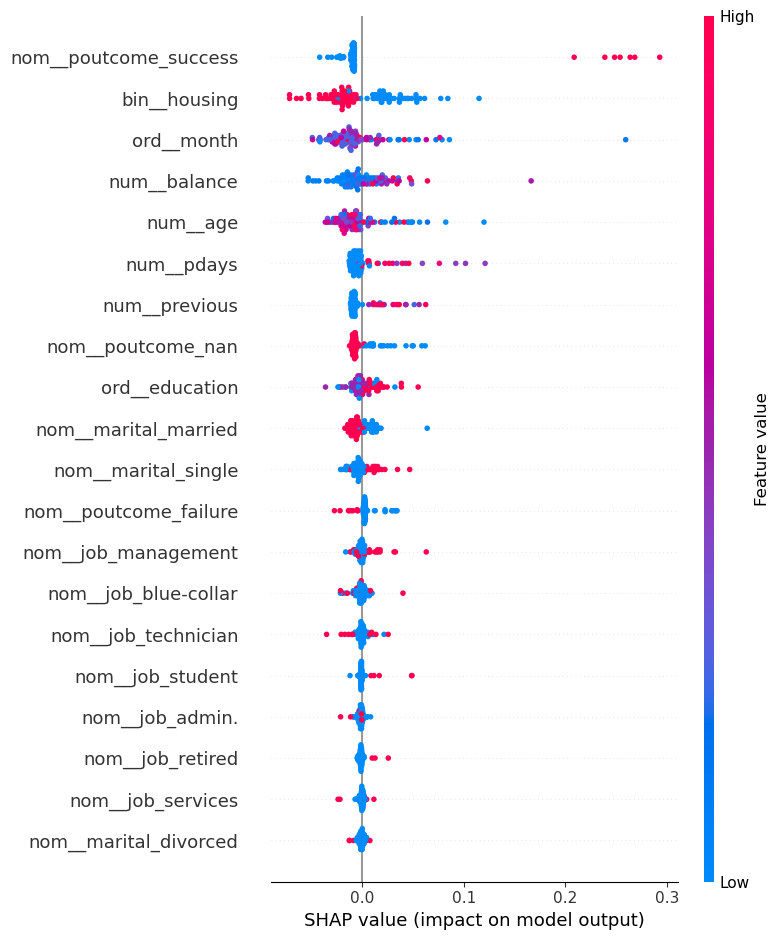

In [17]:

# Per un problema binario shap_values è una lista con un array per classe
shap_values_positive = shap_values[:,:,1]

# Nota: il summary plot userà i nomi delle feature trasformate (post-encoding)
shap.summary_plot(shap_values_positive, X_test_sample_transformed, show=True)

<a id="sintesi"></a>
## Sintesi operativa

Il percorso di validazione ha portato a tre risultati principali:

1. **Misura della qualità predittiva**: AUROC e AUPR sul test set offrono una base numerica per dire se il PoC
   è in linea con le aspettative del business, tenendo conto dello sbilanciamento del dataset.
2. **Lettura degli errori**: la matrice di confusione consente di quantificare falsi positivi e falsi negativi,
   collegando direttamente le prestazioni del modello a costi e opportunità della campagna.
3. **Fattori chiave individuati**: PFI e SHAP summary plot mostrano quali feature guidano le previsioni e in che direzione,
   preparando il terreno per un confronto con il team marketing sulle leve più efficaci.

Il PoC non si esaurisce in un numero di metrica, ma in un quadro coerente di prestazioni ed elementi interpretativi
su cui costruire eventuali iterazioni successive.
